# **Applied Machine Learning Lab-(MCSE630P)**


**Assignment 5- KNN Classifier**

**Name:** Shrihariharan S [24MCS1058]

**Decision Tree :**

* Taken KNN Claasifier dataset from Kaggle https://www.kaggle.com/competitions/problem1-bank-customer-churn-prediction
* Converting the ordinal and nominal data in the dataset to numerical data using one hot encoding and Lable encoding
* scaling the larger values to smaller values using standard scalar for Normalization
* Found outliers in dataset using boxblot and capped it using IQR method
* Found the corelation between dependent and independent variable using heat map
* split the dataset into training and test data
* trained the model KNNClassifier using training data and predicted the value of y_pred using test data.

* compared the actual y_test value with predicted y_pred value and found the accuracy score
* Used Grid search for trying with various Parameters and found out the best parameter for this model
* Trained the model using the best Parameters from Grid search
* Predicted the accuracy that Model
* Used SMOTE technique as the additional learning part



In [502]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [503]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [504]:
#connection with kaggle
! pip install -q kaggle

In [505]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [506]:
#downloading dataset from kaggle
! kaggle competitions download -c problem1-bank-customer-churn-prediction


Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 8, in <module>
    sys.exit(main())
  File "/usr/local/lib/python3.10/dist-packages/kaggle/cli.py", line 63, in main
    out = args.func(**command_args)
  File "/usr/local/lib/python3.10/dist-packages/kaggle/api/kaggle_api_extended.py", line 1037, in competition_download_cli
    self.competition_download_files(competition, path, force,
  File "/usr/local/lib/python3.10/dist-packages/kaggle/api/kaggle_api_extended.py", line 1000, in competition_download_files
    url = response.retries.history[0].redirect_location.split('?')[0]
IndexError: tuple index out of range


In [507]:
#unzipping the downloaded zip file
#!unzip /content/problem1-bank-customer-churn-prediction.zip #un

In [508]:
#reading the csv file and storing it in dataframe df
df=pd.read_csv('/content/train.csv')



In [509]:
# checking for counts and values in Exited column
df['Exited'].value_counts()

,count
Exited,
0,10810
1,2691


In [510]:
#last 5 rows of record
df.tail()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
13496,13496,15676966.0,Cremonesi,589,Spain,Male,35,4,101993.12,1,1,0,143681.85,0
13497,13497,15796834.0,Uspenskaya,744,Spain,Male,34,8,0.00,1,1,1,10963.04,0
13498,13498,15708904.0,Hsia,745,France,Female,36,9,0.00,1,0,1,63889.10,1
13499,13499,15723008.0,Hsu,659,Spain,Male,37,9,130142.79,1,0,1,193502.93,0
13500,13500,15761148.0,Ch'iu,622,France,Female,41,3,0.00,2,1,0,174431.01,0


In [511]:
#checking rows and column
df.shape

(13501, 14)

In [512]:
df.head() #first 5 rows of record

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15611794.0,Walker,667,France,Male,33,5,0.0,2,1,1,145562.40,0
1,1,15803032.0,Hsiung,653,Germany,Female,34,1,152532.3,1,1,0,67972.45,0
2,2,15631170.0,Walker,656,France,Male,30,5,0.0,2,1,0,69052.87,0
3,3,15761733.0,Ch'eng,704,France,Male,40,1,0.0,1,1,1,165561.82,0
4,4,15682070.0,Mazzanti,642,France,Male,32,2,0.0,2,1,0,582.59,0


In [513]:
df.shape

(13501, 14)

In [514]:
#information od dataframe, with datatype, nullvalues,etc..
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13501 entries, 0 to 13500
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               13501 non-null  int64  
 1   CustomerId       13501 non-null  float64
 2   Surname          13501 non-null  object 
 3   CreditScore      13501 non-null  int64  
 4   Geography        13501 non-null  object 
 5   Gender           13501 non-null  object 
 6   Age              13501 non-null  int64  
 7   Tenure           13501 non-null  int64  
 8   Balance          13501 non-null  float64
 9   NumOfProducts    13501 non-null  int64  
 10  HasCrCard        13501 non-null  int64  
 11  IsActiveMember   13501 non-null  int64  
 12  EstimatedSalary  13501 non-null  float64
 13  Exited           13501 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.4+ MB


In [515]:
#description of dataframe mean, median, min, max, etc,...
df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,13501.000000,1.350100e+04,13501.000000,13501.000000,13501.000000,1.350100e+04,13501.000000,13501.000000,13501.000000,13501.000000,13501.000000
mean,6750.000000,1.568993e+07,658.374195,37.708985,5.035997,4.342717e+04,1.585068,0.783349,0.493223,117408.724692,0.199319
std,3897.547327,2.021209e+05,73.149470,8.256677,2.800985,6.169027e+04,0.532468,0.411978,0.499973,45732.107253,0.399503
min,0.000000,1.557227e+05,431.000000,18.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000,11.580000,0.000000
25%,3375.000000,1.563427e+07,602.000000,32.000000,3.000000,0.000000e+00,1.000000,1.000000,0.000000,82969.610000,0.000000
50%,6750.000000,1.568908e+07,661.000000,37.000000,5.000000,0.000000e+00,2.000000,1.000000,0.000000,122925.400000,0.000000
75%,10125.000000,1.575786e+07,709.000000,42.000000,7.000000,1.099881e+05,2.000000,1.000000,1.000000,156495.390000,0.000000
max,13500.000000,1.581564e+07,850.000000,74.000000,10.000000,1.665901e+06,4.000000,1.000000,1.000000,199992.480000,1.000000


In [516]:
df.tail()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
13496,13496,15676966.0,Cremonesi,589,Spain,Male,35,4,101993.12,1,1,0,143681.85,0
13497,13497,15796834.0,Uspenskaya,744,Spain,Male,34,8,0.00,1,1,1,10963.04,0
13498,13498,15708904.0,Hsia,745,France,Female,36,9,0.00,1,0,1,63889.10,1
13499,13499,15723008.0,Hsu,659,Spain,Male,37,9,130142.79,1,0,1,193502.93,0
13500,13500,15761148.0,Ch'iu,622,France,Female,41,3,0.00,2,1,0,174431.01,0


In [517]:
df.isnull().sum() #checking for null values

,0
id,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [518]:
df.value_counts("Geography")

,count
Geography,
France,8106
Spain,2949
Germany,2446


In [519]:
#coverting nomial/dicrete values to numerical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Geography"]=le.fit_transform(df["Geography"])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15611794.0,Walker,667,0,Male,33,5,0.0,2,1,1,145562.40,0
1,1,15803032.0,Hsiung,653,1,Female,34,1,152532.3,1,1,0,67972.45,0
2,2,15631170.0,Walker,656,0,Male,30,5,0.0,2,1,0,69052.87,0
3,3,15761733.0,Ch'eng,704,0,Male,40,1,0.0,1,1,1,165561.82,0
4,4,15682070.0,Mazzanti,642,0,Male,32,2,0.0,2,1,0,582.59,0


In [520]:
df.value_counts("Geography")

,count
Geography,
0,8106
2,2949
1,2446


In [521]:
dummies= pd.get_dummies(df["Gender"]) #converting the categorical data to numerical data one hot Encoding
dummies

,Female,Male
0,False,True
1,True,False
2,False,True
3,False,True
4,False,True
...,...,...
13496,False,True
13497,False,True
13498,True,False
13499,False,True


In [522]:
# adding the dummies into dataframe
df= pd.concat([df, dummies], axis="columns")
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,Walker,667,0,Male,33,5,0.0,2,1,1,145562.40,0,False,True
1,1,15803032.0,Hsiung,653,1,Female,34,1,152532.3,1,1,0,67972.45,0,True,False
2,2,15631170.0,Walker,656,0,Male,30,5,0.0,2,1,0,69052.87,0,False,True
3,3,15761733.0,Ch'eng,704,0,Male,40,1,0.0,1,1,1,165561.82,0,False,True
4,4,15682070.0,Mazzanti,642,0,Male,32,2,0.0,2,1,0,582.59,0,False,True


In [523]:
#removing gender as one hot encoding is done for it and it is added in the dataframe
df.drop("Gender", axis="columns", inplace=True)
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,Walker,667,0,33,5,0.0,2,1,1,145562.40,0,False,True
1,1,15803032.0,Hsiung,653,1,34,1,152532.3,1,1,0,67972.45,0,True,False
2,2,15631170.0,Walker,656,0,30,5,0.0,2,1,0,69052.87,0,False,True
3,3,15761733.0,Ch'eng,704,0,40,1,0.0,1,1,1,165561.82,0,False,True
4,4,15682070.0,Mazzanti,642,0,32,2,0.0,2,1,0,582.59,0,False,True


In [524]:
#converting boolean into numerical
df["Female"]=df["Female"].astype(int)
df["Male"]=df["Male"].astype(int)
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,Walker,667,0,33,5,0.0,2,1,1,145562.40,0,0,1
1,1,15803032.0,Hsiung,653,1,34,1,152532.3,1,1,0,67972.45,0,1,0
2,2,15631170.0,Walker,656,0,30,5,0.0,2,1,0,69052.87,0,0,1
3,3,15761733.0,Ch'eng,704,0,40,1,0.0,1,1,1,165561.82,0,0,1
4,4,15682070.0,Mazzanti,642,0,32,2,0.0,2,1,0,582.59,0,0,1


In [525]:
df['Surname'].value_counts()

,count
Surname,
Ch'iu,261
Ch'ang,235
Ch'ien,213
Hsia,170
Maclean,158
...,...
Gidney,1
Kenechi,1
Shoebridge,1


In [526]:
#coverting nomial/dicrete values to numerical using LabelEncoder

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Surname"]=le.fit_transform(df["Surname"])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,694,667,0,33,5,0.0,2,1,1,145562.40,0,0,1
1,1,15803032.0,295,653,1,34,1,152532.3,1,1,0,67972.45,0,1,0
2,2,15631170.0,694,656,0,30,5,0.0,2,1,0,69052.87,0,0,1
3,3,15761733.0,71,704,0,40,1,0.0,1,1,1,165561.82,0,0,1
4,4,15682070.0,415,642,0,32,2,0.0,2,1,0,582.59,0,0,1


In [527]:
#scaling the values for normalization to avoid more influence of this column in the prediction
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['Balance'] = sc.fit_transform(df[['Balance']])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,694,667,0,33,5,-0.703981,2,1,1,145562.40,0,0,1
1,1,15803032.0,295,653,1,34,1,1.768661,1,1,0,67972.45,0,1,0
2,2,15631170.0,694,656,0,30,5,-0.703981,2,1,0,69052.87,0,0,1
3,3,15761733.0,71,704,0,40,1,-0.703981,1,1,1,165561.82,0,0,1
4,4,15682070.0,415,642,0,32,2,-0.703981,2,1,0,582.59,0,0,1


In [528]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['EstimatedSalary'] = sc.fit_transform(df[['EstimatedSalary']])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,694,667,0,33,5,-0.703981,2,1,1,0.615644,0,0,1
1,1,15803032.0,295,653,1,34,1,1.768661,1,1,0,-1.081037,0,1,0
2,2,15631170.0,694,656,0,30,5,-0.703981,2,1,0,-1.057411,0,0,1
3,3,15761733.0,71,704,0,40,1,-0.703981,1,1,1,1.052977,0,0,1
4,4,15682070.0,415,642,0,32,2,-0.703981,2,1,0,-2.554670,0,0,1


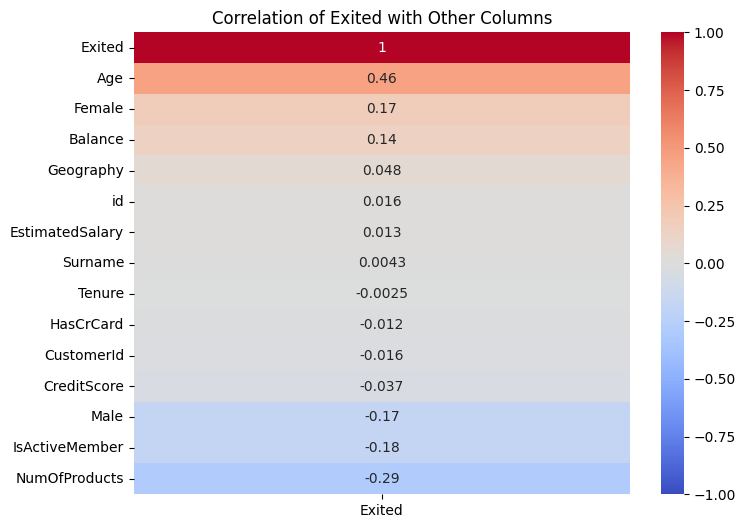

In [529]:
#Finding co-relation using heatmap
corr_matrix = df.corr()

ten_year_chd_corr = corr_matrix[['Exited']].sort_values(by='Exited', ascending=False)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ten_year_chd_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Exited with Other Columns')
plt.show()

<Axes: ylabel='Age'>

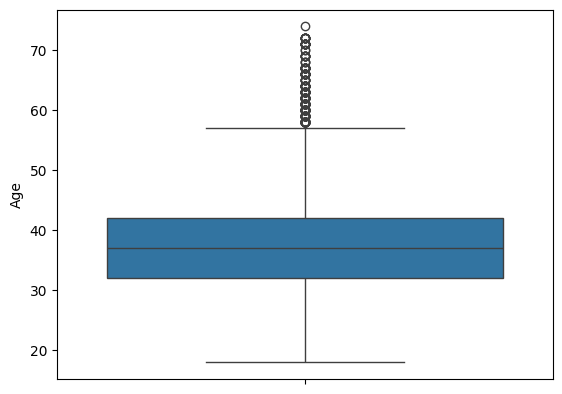

In [530]:
#boxplot for finding outlier
sns.boxplot(df['Age'])

<Axes: ylabel='Balance'>

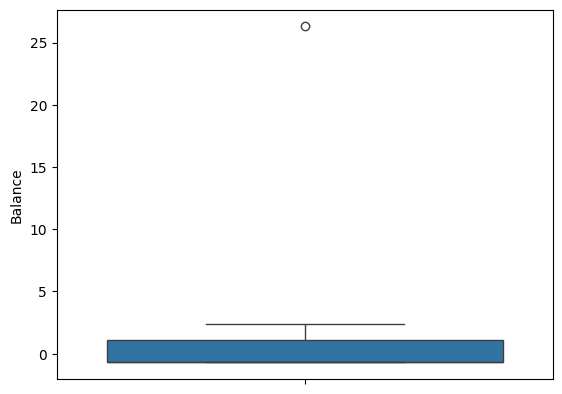

In [531]:
sns.boxplot(df['Balance'])

<Axes: ylabel='EstimatedSalary'>

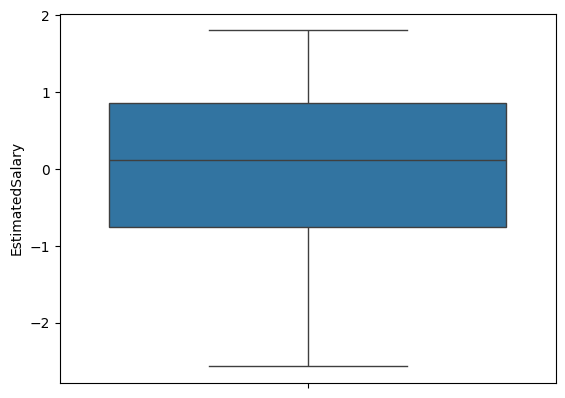

In [532]:
sns.boxplot(df['EstimatedSalary'])

In [533]:
#capping the outlier using IQR method
q1_age =df['Age'].quantile(0.25)
q3_age =df['Age'].quantile(0.75)
iqr_age = q3_age - q1_age

lower_bound_age = q1_age - 1.5 * iqr_age
upper_bound_age = q3_age + 1.5 * iqr_age

In [534]:
df.shape

(13501, 15)

In [535]:
df.loc[ df['Age'] > upper_bound_age, 'Age'] = upper_bound_age
df.loc[ df['Age'] < lower_bound_age, 'Age'] = lower_bound_age

<Axes: ylabel='Age'>

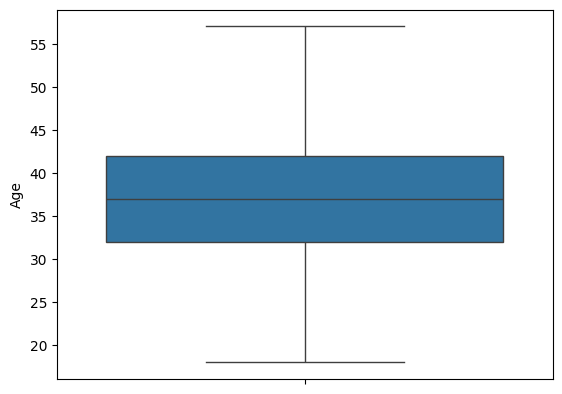

In [536]:
sns.boxplot(df['Age'])

In [537]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,694,667,0,33,5,-0.703981,2,1,1,0.615644,0,0,1
1,1,15803032.0,295,653,1,34,1,1.768661,1,1,0,-1.081037,0,1,0
2,2,15631170.0,694,656,0,30,5,-0.703981,2,1,0,-1.057411,0,0,1
3,3,15761733.0,71,704,0,40,1,-0.703981,1,1,1,1.052977,0,0,1
4,4,15682070.0,415,642,0,32,2,-0.703981,2,1,0,-2.554670,0,0,1


In [538]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["CustomerId"]=le.fit_transform(df["CustomerId"])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,1082,694,667,0,33,5,-0.703981,2,1,1,0.615644,0,0,1
1,1,5741,295,653,1,34,1,1.768661,1,1,0,-1.081037,0,1,0
2,2,1461,694,656,0,30,5,-0.703981,2,1,0,-1.057411,0,0,1
3,3,4643,71,704,0,40,1,-0.703981,1,1,1,1.052977,0,0,1
4,4,2775,415,642,0,32,2,-0.703981,2,1,0,-2.554670,0,0,1


In [539]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13501 entries, 0 to 13500
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               13501 non-null  int64  
 1   CustomerId       13501 non-null  int64  
 2   Surname          13501 non-null  int64  
 3   CreditScore      13501 non-null  int64  
 4   Geography        13501 non-null  int64  
 5   Age              13501 non-null  int64  
 6   Tenure           13501 non-null  int64  
 7   Balance          13501 non-null  float64
 8   NumOfProducts    13501 non-null  int64  
 9   HasCrCard        13501 non-null  int64  
 10  IsActiveMember   13501 non-null  int64  
 11  EstimatedSalary  13501 non-null  float64
 12  Exited           13501 non-null  int64  
 13  Female           13501 non-null  int64  
 14  Male             13501 non-null  int64  
dtypes: float64(2), int64(13)
memory usage: 1.5 MB


In [540]:
df

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,1082,694,667,0,33,5,-0.703981,2,1,1,0.615644,0,0,1
1,1,5741,295,653,1,34,1,1.768661,1,1,0,-1.081037,0,1,0
2,2,1461,694,656,0,30,5,-0.703981,2,1,0,-1.057411,0,0,1
3,3,4643,71,704,0,40,1,-0.703981,1,1,1,1.052977,0,0,1
4,4,2775,415,642,0,32,2,-0.703981,2,1,0,-2.554670,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13496,13496,2646,160,589,2,35,4,0.949390,1,1,0,0.574522,0,0,1
13497,13497,5599,687,744,2,34,8,-0.703981,1,1,1,-2.327678,0,0,1
13498,13498,3462,291,745,0,36,9,-0.703981,1,0,1,-1.170329,1,1,0
13499,13499,3724,297,659,2,37,9,1.405713,1,0,1,1.663974,0,0,1


In [541]:
#splitting dependent and independent variables
x=pd.DataFrame(df.drop(['Exited'], axis=1))
y=pd.DataFrame(df['Exited'])

In [542]:
# spliting the data into training and testing data
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=1)

In [543]:
from sklearn.neighbors import KNeighborsClassifier
knnclassifier=KNeighborsClassifier(n_neighbors=5,metric='minkowski',p=2)
knnclassifier.fit(X_train,y_train)


/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:233: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [544]:
y_pred=knnclassifier.predict(X_test)

In [545]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
acc=accuracy_score(y_test,y_pred)

In [546]:
print(cm)
print(acc)

[[3364  246]
 [ 781   65]]
0.769524236983842


In [547]:
grid_par={'n_neighbors':[5,6,7,8,9,10], 'weights':['uniform', 'distance'], 'metric':['euclidean','manhattan']}

In [548]:
from sklearn.model_selection import GridSearchCV

In [549]:
gs=GridSearchCV(KNeighborsClassifier(),grid_par,verbose=1, cv=5, n_jobs=-1)

In [550]:
grid_res=gs.fit(X_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:233: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [551]:
grid_res.best_score_

0.7925925925925925

In [552]:
grid_res.best_params_

{'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'uniform'}

In [553]:
#using the tuned parameters
knnclassifier=KNeighborsClassifier(n_neighbors=10,metric='manhattan',weights= 'uniform')
knnclassifier.fit(X_train,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:233: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(metric='manhattan', n_neighbors=10)

In [554]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9045, 14), (4456, 14), (9045, 1), (4456, 1))

In [555]:
y_pred1 = knnclassifier.predict(X_test)

In [556]:
cm=confusion_matrix(y_test,y_pred1)
acc=accuracy_score(y_test,y_pred1)

In [557]:
classy_rep=classification_report(y_test,y_pred1)
print(classy_rep)

              precision    recall  f1-score   support

           0       0.81      0.99      0.89      3610
           1       0.16      0.00      0.01       846

    accuracy                           0.81      4456
   macro avg       0.48      0.50      0.45      4456
weighted avg       0.69      0.81      0.72      4456



In [558]:
print(cm)
print(acc)

[[3589   21]
 [ 842    4]]
0.8063285457809695


**ADDITIONAL LEARNING**

SMOTE TECHNIQUE

In [559]:
x.shape,y.shape

((13501, 14), (13501, 1))

In [560]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9045, 14), (4456, 14), (9045, 1), (4456, 1))

In [561]:
!pip install imblearn


In [562]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [569]:
X_resampled.shape, y_resampled.shape, X_test.shape, y_test.shape

((14400, 14), (14400, 1), (4456, 14), (4456, 1))

In [567]:
from sklearn.neighbors import KNeighborsClassifier
knnclassifier.fit(X_resampled,y_resampled)

y_pred2=knnclassifier.predict(X_test)

from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred2)
acc=accuracy_score(y_test,y_pred2)

print(cm)
print(acc)

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:233: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


[[2265 1345]
 [ 497  349]]
0.5866247755834829


In [570]:
classy_rep1=classification_report(y_test,y_pred2)
print(classy_rep1)

              precision    recall  f1-score   support

           0       0.82      0.63      0.71      3610
           1       0.21      0.41      0.27       846

    accuracy                           0.59      4456
   macro avg       0.51      0.52      0.49      4456
weighted avg       0.70      0.59      0.63      4456



# **OUTCOME**



*   Without parameter Tuning we got KNeighborsClassifier as accuracy of 76.9524236983842 %
*  Using the Grid search we found the optimum parameters for tuning the model and got the improved accuracy of 80.63285457809695 %
* As there is an class imbalance in Classification, we tried upsampling the dataset using SMOTE Techinique and upsampled the dataset. But there is an reduction in accuracy score.
* on observation with Classification report, after upsampling, model is good in predicting the 1 value as well, the recall and f1 score of the classifier 1 is increased considerably

